In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time


In [2]:
# ============================================================
# FUNGSI EVALUASI
# ============================================================

def mse(img1, img2):
    return np.mean((img1.astype("float") - img2.astype("float")) ** 2)

def psnr(img1, img2):
    mse_value = mse(img1, img2)
    if mse_value == 0:
        return 100
    return 20 * np.log10(255.0 / np.sqrt(mse_value))

def evaluate(original, transformed, name, comp_time):
    resized = cv2.resize(transformed, (original.shape[1], original.shape[0]))
    m = mse(original, resized)
    p = psnr(original, resized)

    print(f"{name}")
    print(f"MSE   : {m:.2f}")
    print(f"PSNR  : {p:.2f}")
    print(f"Waktu : {comp_time:.10f} detik")
    print("-"*50)

In [3]:
# ============================================================
# LOAD CITRA
# ============================================================

img1 = cv2.imread("lurus.jpeg")
img2 = cv2.imread("miring.jpeg")

if img1 is None or img2 is None:
    print("Gambar tidak ditemukan!")
    exit()

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

h1, w1 = img1.shape[:2]
h2, w2 = img2.shape[:2]


In [4]:
# ============================================================
# PARAMETER
# ============================================================

tx, ty = 80, 40
angle = 30
sx, sy = 0.7, 0.7

pts1 = np.float32([[50,50], [200,50], [50,300]])
pts2 = np.float32([[10,100], [200,50], [100,300]])

src_pts = np.float32([[100,50], [400,50], [80,600], [420,600]])
dst_pts = np.float32([[100,50], [400,50], [100,600], [400,600]])


In [5]:
# ============================================================
# FUNGSI TRANSFORMASI
# ============================================================

def apply_transforms(img, w, h):

    results = {}
    times = {}

    # Translasi
    start = time.time()
    T = np.array([[1, 0, tx],
                  [0, 1, ty]], dtype=np.float32)
    results["Translasi"] = cv2.warpAffine(img, T, (w, h))
    times["Translasi"] = time.time() - start

    # Rotasi
    start = time.time()
    theta = np.deg2rad(angle)
    cx, cy = w // 2, h // 2
    R = np.array([
        [np.cos(theta), -np.sin(theta), (1-np.cos(theta))*cx + np.sin(theta)*cy],
        [np.sin(theta),  np.cos(theta), (1-np.sin(theta))*cy - np.sin(theta)*cx]
    ], dtype=np.float32)
    results["Rotasi"] = cv2.warpAffine(img, R, (w, h))
    times["Rotasi"] = time.time() - start

    # Scaling
    start = time.time()
    S = np.array([[sx, 0, 0],
                  [0, sy, 0]], dtype=np.float32)
    results["Scaling"] = cv2.warpAffine(img, S, (int(w*sx), int(h*sy)))
    times["Scaling"] = time.time() - start

    # Affine
    start = time.time()
    M_affine = cv2.getAffineTransform(pts1, pts2)
    results["Affine"] = cv2.warpAffine(img, M_affine, (w, h))
    times["Affine"] = time.time() - start

    # Perspective (tanpa interpolasi khusus)
    start = time.time()
    M_persp = cv2.getPerspectiveTransform(src_pts, dst_pts)
    results["Perspective"] = cv2.warpPerspective(img, M_persp, (w, h))
    times["Perspective"] = time.time() - start

    return results, times

In [6]:
# ============================================================
# TERAPKAN TRANSFORMASI
# ============================================================

results1, times1 = apply_transforms(img1, w1, h1)
results2, times2 = apply_transforms(img2, w2, h2)

In [7]:
# ============================================================
# EVALUASI INTERNAL
# ============================================================

print("\n===== EVALUASI IMAGE 1 =====\n")
for name in results1:
    evaluate(img1, results1[name], name, times1[name])

print("\n===== EVALUASI IMAGE 2 =====\n")
for name in results2:
    evaluate(img2, results2[name], name, times2[name])


===== EVALUASI IMAGE 1 =====

Translasi
MSE   : 3016.79
PSNR  : 13.34
Waktu : 0.0069589615 detik
--------------------------------------------------
Rotasi
MSE   : 4659.69
PSNR  : 11.45
Waktu : 0.0032944679 detik
--------------------------------------------------
Scaling
MSE   : 62.61
PSNR  : 30.16
Waktu : 0.0020728111 detik
--------------------------------------------------
Affine
MSE   : 4425.29
PSNR  : 11.67
Waktu : 0.0038537979 detik
--------------------------------------------------
Perspective
MSE   : 2803.05
PSNR  : 13.65
Waktu : 0.0096466541 detik
--------------------------------------------------

===== EVALUASI IMAGE 2 =====

Translasi
MSE   : 7362.83
PSNR  : 9.46
Waktu : 0.0023415089 detik
--------------------------------------------------
Rotasi
MSE   : 10655.27
PSNR  : 7.86
Waktu : 0.0023570061 detik
--------------------------------------------------
Scaling
MSE   : 73.12
PSNR  : 29.49
Waktu : 0.0012311935 detik
--------------------------------------------------
Affine
MSE

In [8]:
# ============================================================
# 🔥 INTERPOLASI HANYA PADA PERSPECTIVE
# ============================================================

methods = {
    "Nearest": cv2.INTER_NEAREST,
    "Bilinear": cv2.INTER_LINEAR,
    "Bicubic": cv2.INTER_CUBIC
}

print("\n===== INTERPOLASI PERSPECTIVE IMAGE 1 =====\n")
for name, method in methods.items():
    start = time.time()
    interp = cv2.warpPerspective(
        img1,
        cv2.getPerspectiveTransform(src_pts, dst_pts),
        (w1, h1),
        flags=method
    )
    evaluate(img1, interp, f"Perspective + {name}", time.time()-start)


print("\n===== INTERPOLASI PERSPECTIVE IMAGE 2 =====\n")
for name, method in methods.items():
    start = time.time()
    interp = cv2.warpPerspective(
        img2,
        cv2.getPerspectiveTransform(src_pts, dst_pts),
        (w2, h2),
        flags=method
    )
    evaluate(img2, interp, f"Perspective + {name}", time.time()-start)



===== INTERPOLASI PERSPECTIVE IMAGE 1 =====

Perspective + Nearest
MSE   : 2823.69
PSNR  : 13.62
Waktu : 0.0043263435 detik
--------------------------------------------------
Perspective + Bilinear
MSE   : 2803.05
PSNR  : 13.65
Waktu : 0.0035083294 detik
--------------------------------------------------
Perspective + Bicubic
MSE   : 2820.50
PSNR  : 13.63
Waktu : 0.0672233105 detik
--------------------------------------------------

===== INTERPOLASI PERSPECTIVE IMAGE 2 =====

Perspective + Nearest
MSE   : 5755.23
PSNR  : 10.53
Waktu : 0.0022773743 detik
--------------------------------------------------
Perspective + Bilinear
MSE   : 5723.72
PSNR  : 10.55
Waktu : 0.0031588078 detik
--------------------------------------------------
Perspective + Bicubic
MSE   : 5746.16
PSNR  : 10.54
Waktu : 0.0057442188 detik
--------------------------------------------------


In [9]:
# ============================================================
# TRANSFORMASI SILANG (DALAM DETIK - PRESISI TINGGI)
# ============================================================

print("\n===== TRANSFORMASI IMAGE1 vs ASLI IMAGE2 =====\n")
for key in results1.keys():
    start = time.perf_counter()

    img1_t = cv2.resize(results1[key], (w2, h2))
    m = mse(img2, img1_t)
    p = psnr(img2, img1_t)

    comp_time = time.perf_counter() - start  # dalam detik

    print(f"{key} (Img1 -> Asli Img2)")
    print(f"MSE   : {m:.2f}")
    print(f"PSNR  : {p:.2f}")
    print(f"Waktu : {comp_time:.10f} detik")
    print("-"*50)


print("\n===== TRANSFORMASI IMAGE2 vs ASLI IMAGE1 =====\n")
for key in results2.keys():
    start = time.perf_counter()

    img2_t = cv2.resize(results2[key], (w1, h1))
    m = mse(img1, img2_t)
    p = psnr(img1, img2_t)

    comp_time = time.perf_counter() - start  # dalam detik

    print(f"{key} (Img2 -> Asli Img1)")
    print(f"MSE   : {m:.2f}")
    print(f"PSNR  : {p:.2f}")
    print(f"Waktu : {comp_time:.10f} detik")
    print("-"*50)



===== TRANSFORMASI IMAGE1 vs ASLI IMAGE2 =====

Translasi (Img1 -> Asli Img2)
MSE   : 9199.58
PSNR  : 8.49
Waktu : 0.0587391000 detik
--------------------------------------------------
Rotasi (Img1 -> Asli Img2)
MSE   : 11096.64
PSNR  : 7.68
Waktu : 0.0616898000 detik
--------------------------------------------------
Scaling (Img1 -> Asli Img2)
MSE   : 6570.50
PSNR  : 9.95
Waktu : 0.0565250000 detik
--------------------------------------------------
Affine (Img1 -> Asli Img2)
MSE   : 11039.40
PSNR  : 7.70
Waktu : 0.0563549000 detik
--------------------------------------------------
Perspective (Img1 -> Asli Img2)
MSE   : 9075.40
PSNR  : 8.55
Waktu : 0.0568545000 detik
--------------------------------------------------

===== TRANSFORMASI IMAGE2 vs ASLI IMAGE1 =====

Translasi (Img2 -> Asli Img1)
MSE   : 6840.38
PSNR  : 9.78
Waktu : 0.0632448000 detik
--------------------------------------------------
Rotasi (Img2 -> Asli Img1)
MSE   : 7038.96
PSNR  : 9.66
Waktu : 0.0617104000 detik
-

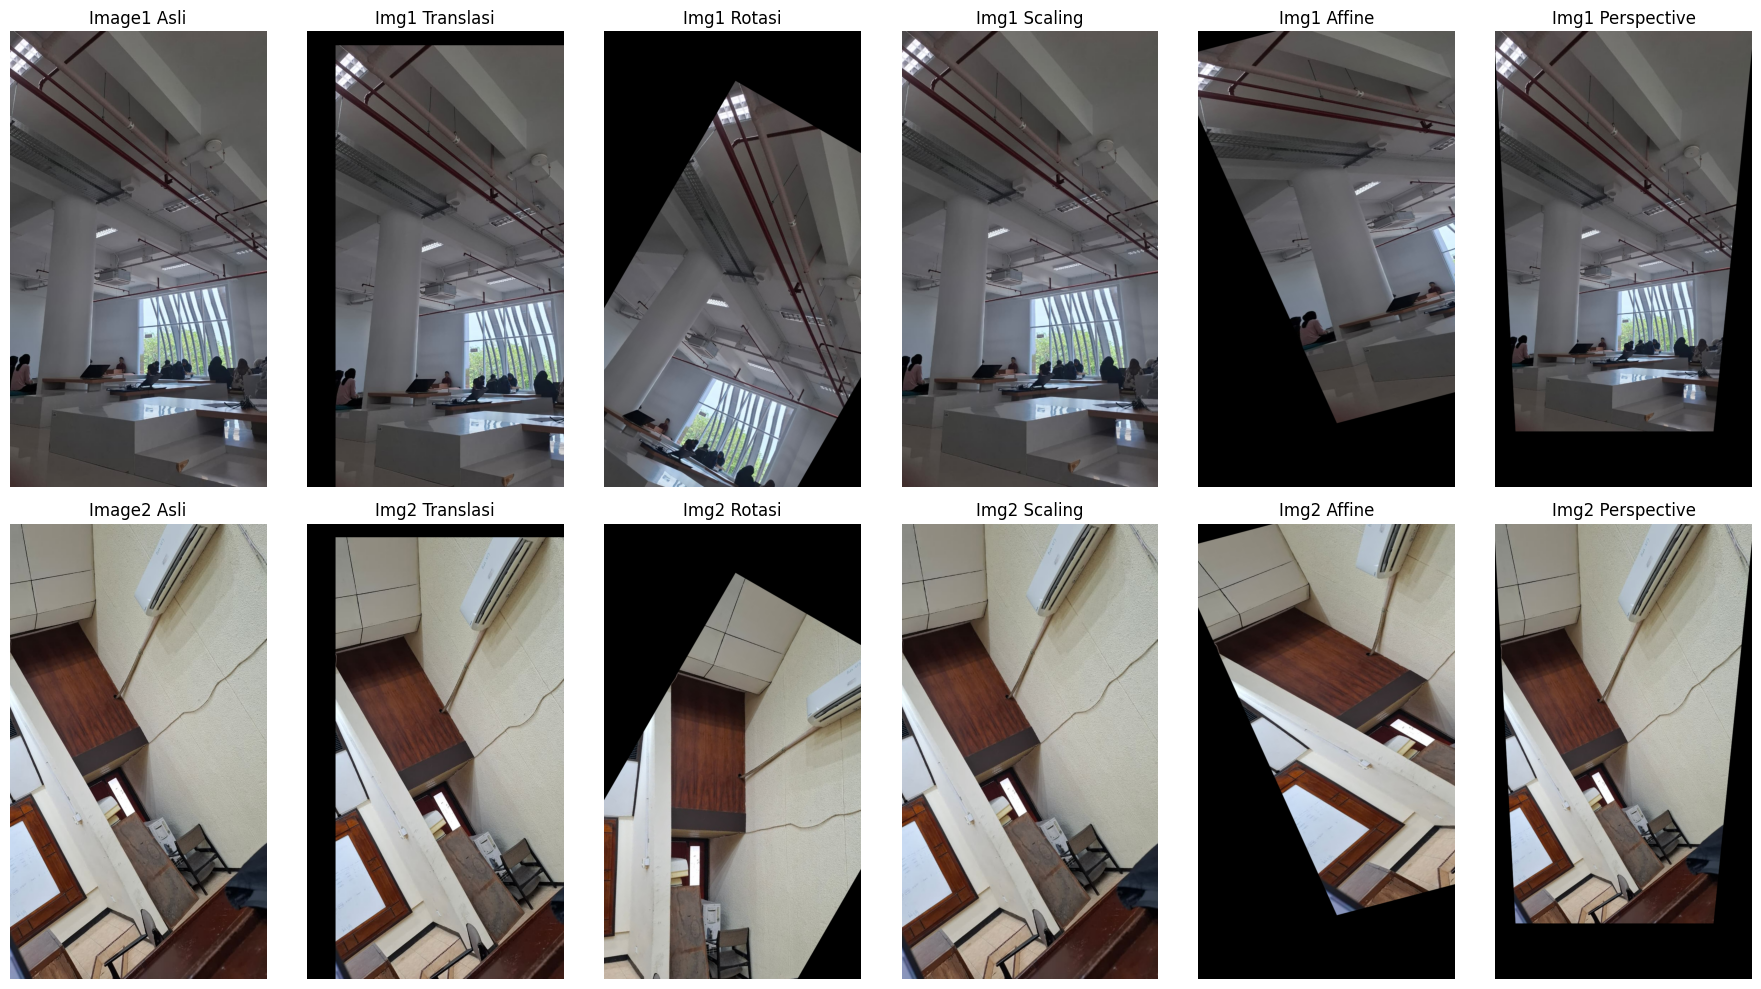

In [10]:
# ============================================================
# VISUALISASI
# ============================================================

plt.figure(figsize=(18,10))

# IMAGE 1
plt.subplot(2,6,1); plt.imshow(img1); plt.title("Image1 Asli"); plt.axis("off")
plt.subplot(2,6,2); plt.imshow(results1["Translasi"]); plt.title("Img1 Translasi"); plt.axis("off")
plt.subplot(2,6,3); plt.imshow(results1["Rotasi"]); plt.title("Img1 Rotasi"); plt.axis("off")
plt.subplot(2,6,4); plt.imshow(results1["Scaling"]); plt.title("Img1 Scaling"); plt.axis("off")
plt.subplot(2,6,5); plt.imshow(results1["Affine"]); plt.title("Img1 Affine"); plt.axis("off")
plt.subplot(2,6,6); plt.imshow(results1["Perspective"]); plt.title("Img1 Perspective"); plt.axis("off")

# IMAGE 2
plt.subplot(2,6,7); plt.imshow(img2); plt.title("Image2 Asli"); plt.axis("off")
plt.subplot(2,6,8); plt.imshow(results2["Translasi"]); plt.title("Img2 Translasi"); plt.axis("off")
plt.subplot(2,6,9); plt.imshow(results2["Rotasi"]); plt.title("Img2 Rotasi"); plt.axis("off")
plt.subplot(2,6,10); plt.imshow(results2["Scaling"]); plt.title("Img2 Scaling"); plt.axis("off")
plt.subplot(2,6,11); plt.imshow(results2["Affine"]); plt.title("Img2 Affine"); plt.axis("off")
plt.subplot(2,6,12); plt.imshow(results2["Perspective"]); plt.title("Img2 Perspective"); plt.axis("off")

plt.tight_layout()
plt.show()